# EMG Gesture Classification Notebook

##  Summary
This project builds a multiclass EMG gesture recognition pipeline from 8-channel forearm signals and compares three modeling strategies under one shared evaluation framework.

Models compared:
1. `MLP` on engineered time-domain EMG features
2. `XGBoost` on the same engineered feature space
3. `CNN-LSTM` on filtered raw signal windows

## To-Do:
1. Quantization
2. Optuna
3. Hyperparameters


## 1. Dataset Context and Scope

**Source:** [UCI EMG data for gestures](https://archive.ics.uci.edu/ml/datasets/EMG+data+for+gestures)

### Experimental Setup (from dataset documentation)
- Device: **MYO Thalmic bracelet**
- Sensors: **8 EMG channels** wrapped around the forearm
- Subjects: **36 participants**
- Task: repeated static hand/wrist gestures with controlled timing

### Schema Used in This Notebook (11 columns)
1. `time` (milliseconds)
2. `channel1`
3. `channel2`
4. `channel3`
5. `channel4`
6. `channel5`
7. `channel6`
8. `channel7`
9. `channel8`
10. `class` (gesture class)
11. `label` (subject ID added for participant tracking)

### Gesture Definitions
- `0`: unmarked
- `1`: hand at rest
- `2`: hand clenched in a fist
- `3`: wrist flexion
- `4`: wrist extension
- `5`: radial deviation
- `6`: ulnar deviation
- `7`: extended palm (missing for some subjects)

### Modeling Scope in This Version
To keep supervision consistent across participants, classes `0` and `7` are removed before training.
This notebook therefore focuses on gestures `1-6`.

### Acknowledgement
Thanks to the UCI Machine Learning Repository and the original authors for making this dataset publicly available.


## 2. Exploratory Data Analysis (EDA)

### EDA Goals
1. Confirm data integrity and identify obvious issues early.
2. Check class balance and how preprocessing changes label frequencies.
3. Understand channel distributions, cross-channel relationships, and potential redundancy.
4. Inspect signal behavior in both time and frequency domains.
5. Validate that window-level labeling is suitable for model training.



### 2.1 Data Ingestion and Integrity Checks

This first EDA block loads the dataset, applies scope filters, and validates that the expected classes remain after preprocessing.

What to verify:
- final shape after dropping unused columns/classes
- resulting class IDs
- first few rows for schema sanity


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global plot styling for a polished, portfolio-ready look.
sns.set_theme(
    style="whitegrid",
    context="talk",
    rc={
        "figure.facecolor": "#F4F7FB",
        "axes.facecolor": "#FBFCFE",
        "axes.edgecolor": "#D5DFEA",
        "grid.color": "#D5DFEA",
        "grid.alpha": 0.45,
        "axes.titleweight": "bold",
        "axes.labelcolor": "#1F2937",
        "xtick.color": "#1F2937",
        "ytick.color": "#1F2937",
    },
)

DATA_PATH = "/content/drive/MyDrive/EMG-data.csv" # Updated path to match the error traceback

FS = 200.0
WINDOW_SIZE = 100
STEP_SIZE = 50 # Changed to 50 for 50% overlap
DROP_CLASSES = {0, 7}

CHANNELS = [f"channel{i}" for i in range(1, 9)]

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["time", "label"], errors="ignore")
df = df[~df["class"].isin(DROP_CLASSES)].reset_index(drop=True)

CHANNEL_PALETTE = sns.color_palette("icefire", n_colors=len(CHANNELS))
CLASS_ORDER = sorted(df["class"].unique().tolist())
CLASS_PALETTE = dict(zip(CLASS_ORDER, sns.color_palette("crest", n_colors=len(CLASS_ORDER))))

print("df shape:", df.shape)
print("classes:", sorted(df["class"].unique().tolist()))
df.head()

df shape: (1499055, 9)
classes: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, nan]


,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class
0,-0.00001,0.00000,-0.00001,0.00000,0.00000,-0.00001,-0.00001,0.00001,1.0
1,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1.0
2,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1.0
3,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1.0
4,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1.0


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Missing values (top):


,0
class,1
channel1,0
channel2,0
channel4,0
channel3,0
channel5,0
channel6,0
channel7,0
channel8,0


,count
class,
1.0,250055
2.0,243193
3.0,249494
4.0,251570
5.0,251733
6.0,253009


/tmp/ipykernel_4255/1461903994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette=bar_colors, ax=ax, edgecolor="#334155", linewidth=0.9)


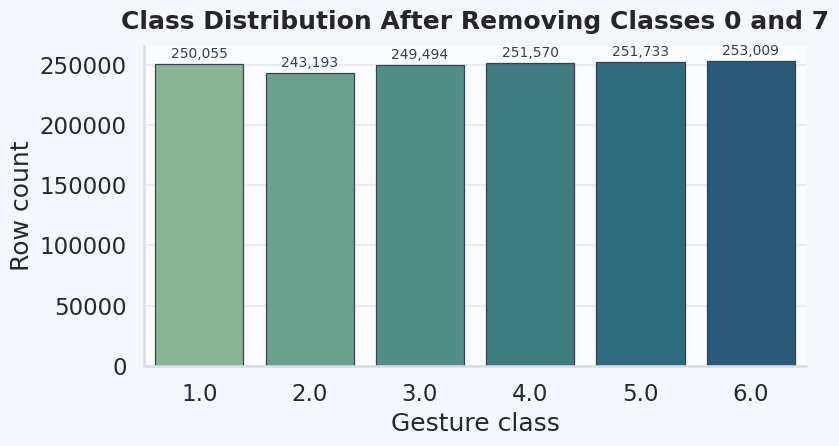

In [8]:
print("Missing values (top):")
display(df.isna().sum().sort_values(ascending=False).head(12))

counts = df["class"].value_counts().sort_index()
display(counts)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bar_colors = [CLASS_PALETTE[int(c)] for c in counts.index]
sns.barplot(x=counts.index.astype(str), y=counts.values, palette=bar_colors, ax=ax, edgecolor="#334155", linewidth=0.9)

for patch, val in zip(ax.patches, counts.values):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + counts.values.max() * 0.01,
        f"{int(val):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#334155",
    )

ax.set_title("Class Distribution After Removing Classes 0 and 7", pad=12)
ax.set_xlabel("Gesture class")
ax.set_ylabel("Row count")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


### 2.2 Distribution and Correlation Diagnostics

These plots characterize per-channel value ranges and channel-to-channel relationships.

How to use this block:
- identify channels with unusual amplitude ranges
- detect strong pairwise correlation that may indicate redundancy
- spot suspicious distribution shifts before modeling


KeyboardInterrupt: 

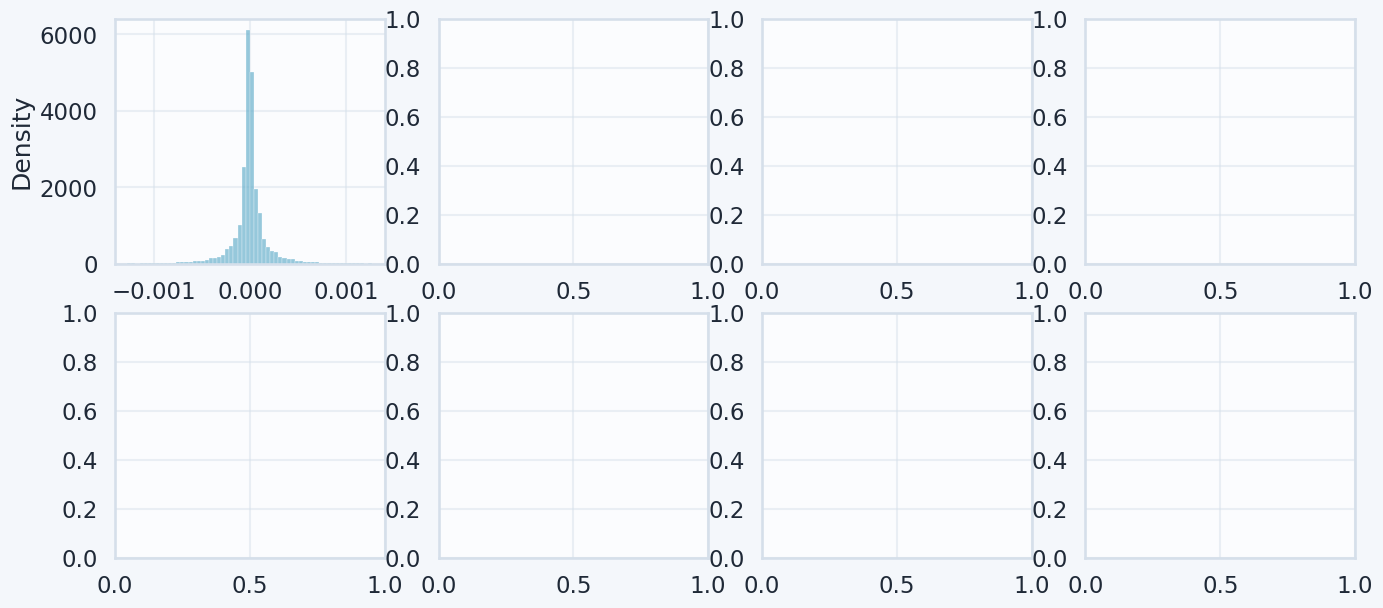

In [9]:
# Histograms
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()
for i, ch in enumerate(CHANNELS):
    ax = axes[i]
    sns.histplot(df[ch].values, bins=60, stat="density", color=CHANNEL_PALETTE[i], alpha=0.7, edgecolor="white", linewidth=0.2, ax=ax)
    sns.kdeplot(df[ch].values, color="#0F172A", linewidth=1.1, ax=ax)
    ax.set_title(ch)
    ax.set_xlabel("Amplitude")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.22)
    sns.despine(ax=ax)

fig.suptitle("Per-Channel EMG Amplitude Distributions", y=1.02)
plt.tight_layout()
plt.show()

# Correlation heatmap
corr = df[CHANNELS].corr()
fig, ax = plt.subplots(figsize=(8.2, 6.2))
sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    cbar_kws={"label": "Correlation", "shrink": 0.85},
    ax=ax,
)
ax.set_title("Channel-to-Channel Correlation Heatmap", pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


### 2.3 Time-Domain and Frequency-Domain Signal Checks

Short raw snippets reveal temporal behavior, while Welch PSD helps confirm dominant frequency structure.

What this tells us:
- whether channels carry distinct temporal patterns
- whether energy is concentrated in expected frequency ranges
- whether filtering choices later are reasonable


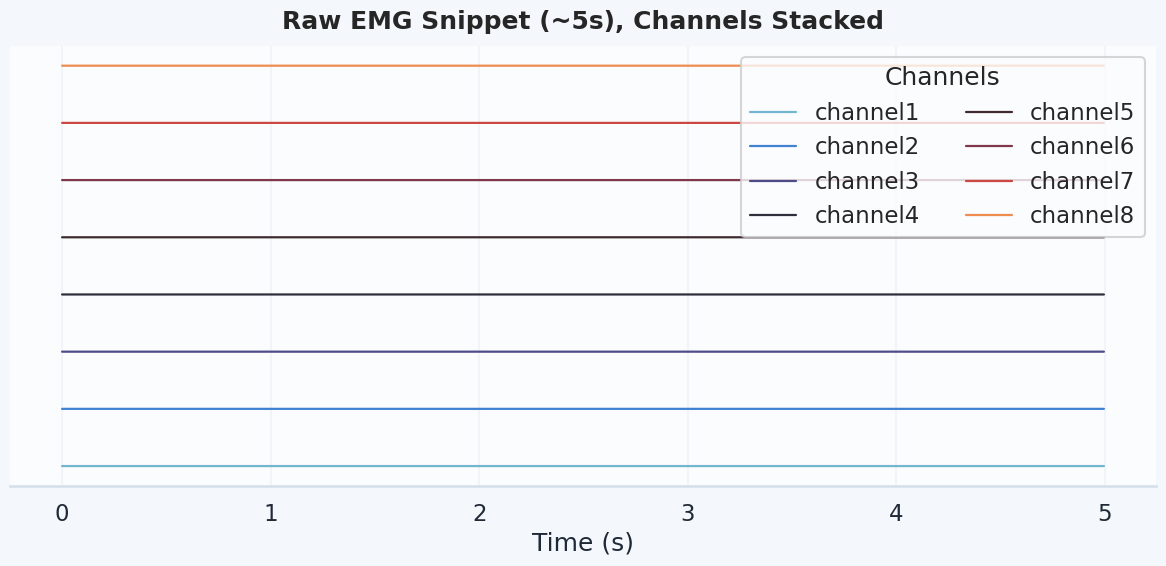

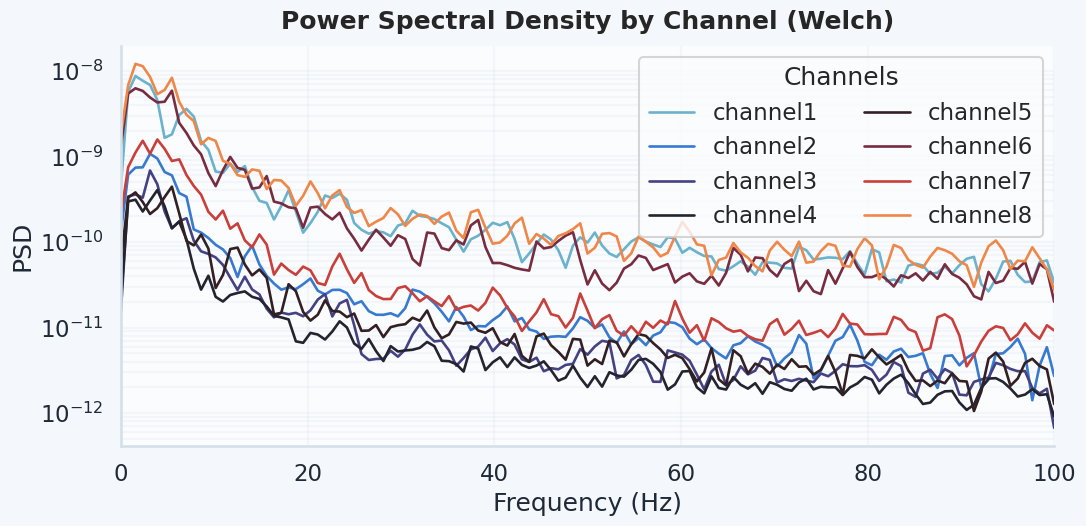

In [10]:
from scipy.signal import welch

rng = np.random.default_rng(42)

# ~5 seconds of raw signal
seg_len = int(5 * FS)
start = int(rng.integers(0, max(1, len(df) - seg_len)))
seg = df.iloc[start:start + seg_len][CHANNELS].to_numpy(dtype=np.float32)
t = np.arange(seg.shape[0]) / FS

fig, ax = plt.subplots(figsize=(12, 6))
offset = 0.6
for i, ch in enumerate(CHANNELS):
    ax.plot(t, seg[:, i] + i * offset, color=CHANNEL_PALETTE[i], linewidth=1.6, alpha=0.95, label=ch)
ax.set_title("Raw EMG Snippet (~5s), Channels Stacked", pad=12)
ax.set_xlabel("Time (s)")
ax.set_yticks([])
ax.legend(loc="upper right", ncol=2, title="Channels")
ax.grid(alpha=0.25)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

# PSD on ~10 seconds
seg_len = int(10 * FS)
start = int(rng.integers(0, max(1, len(df) - seg_len)))
seg = df.iloc[start:start + seg_len][CHANNELS].to_numpy(dtype=np.float32)

fig, ax = plt.subplots(figsize=(11.2, 5.6))
for i, ch in enumerate(CHANNELS):
    f, pxx = welch(seg[:, i], fs=FS, nperseg=min(256, seg.shape[0]))
    ax.semilogy(f, pxx, color=CHANNEL_PALETTE[i], linewidth=1.9, label=ch)
ax.set_title("Power Spectral Density by Channel (Welch)", pad=12)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_xlim(0, FS / 2)
ax.legend(ncol=2, title="Channels")
ax.grid(which="both", alpha=0.22)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


### 2.4 Windowing Strategy and Label Construction

The downstream models are trained on fixed windows rather than row-level samples.

### Window Configuration
- `window_size = 100` samples
- `step_size = 100` samples
- sampling rate `FS = 200 Hz`

This corresponds to a **0.5-second window duration** with **no overlap**.

### Window Label Rule
Each window is assigned the modal class inside that window.
This provides a simple and robust target against occasional row-level label noise near transitions.

### Tradeoffs
- Advantage: lower redundancy and faster training
- Limitation: non-overlapping windows can miss short boundary dynamics

The next outputs verify that the resulting window-level class distribution remains usable.


,count
1,5007
2,4864
3,4985
4,5037
5,5027
6,5060


/tmp/ipykernel_4255/1694957856.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=w_counts.index.astype(str), y=w_counts.values, palette=window_colors, ax=ax, edgecolor="#334155", linewidth=0.9)


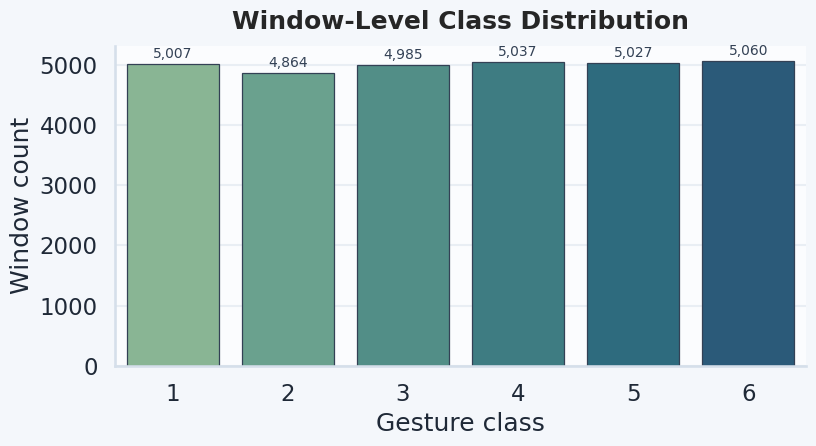

Num windows: 29980


In [11]:
def make_window_starts(n_rows, window_size, step_size):
    return list(range(0, n_rows - window_size + 1, step_size))

def window_labels(df, starts, window_size):
    y = []
    for s in starts:
        w = df.iloc[s:s+window_size]
        y.append(int(w["class"].mode().iloc[0]))
    return np.array(y, dtype=np.int64)

starts = make_window_starts(len(df), WINDOW_SIZE, STEP_SIZE)
y_win = window_labels(df, starts, WINDOW_SIZE)

w_counts = pd.Series(y_win).value_counts().sort_index()
display(w_counts)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
window_colors = [CLASS_PALETTE[int(c)] for c in w_counts.index]
sns.barplot(x=w_counts.index.astype(str), y=w_counts.values, palette=window_colors, ax=ax, edgecolor="#334155", linewidth=0.9)

for patch, val in zip(ax.patches, w_counts.values):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + w_counts.values.max() * 0.01,
        f"{int(val):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#334155",
    )

ax.set_title("Window-Level Class Distribution", pad=12)
ax.set_xlabel("Gesture class")
ax.set_ylabel("Window count")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print("Num windows:", len(starts))


/tmp/ipykernel_4255/1617596795.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4255/1617596795.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4255/1617596795.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4255/1617596795.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4255/1617596795.py:21: FutureWarning: 

P

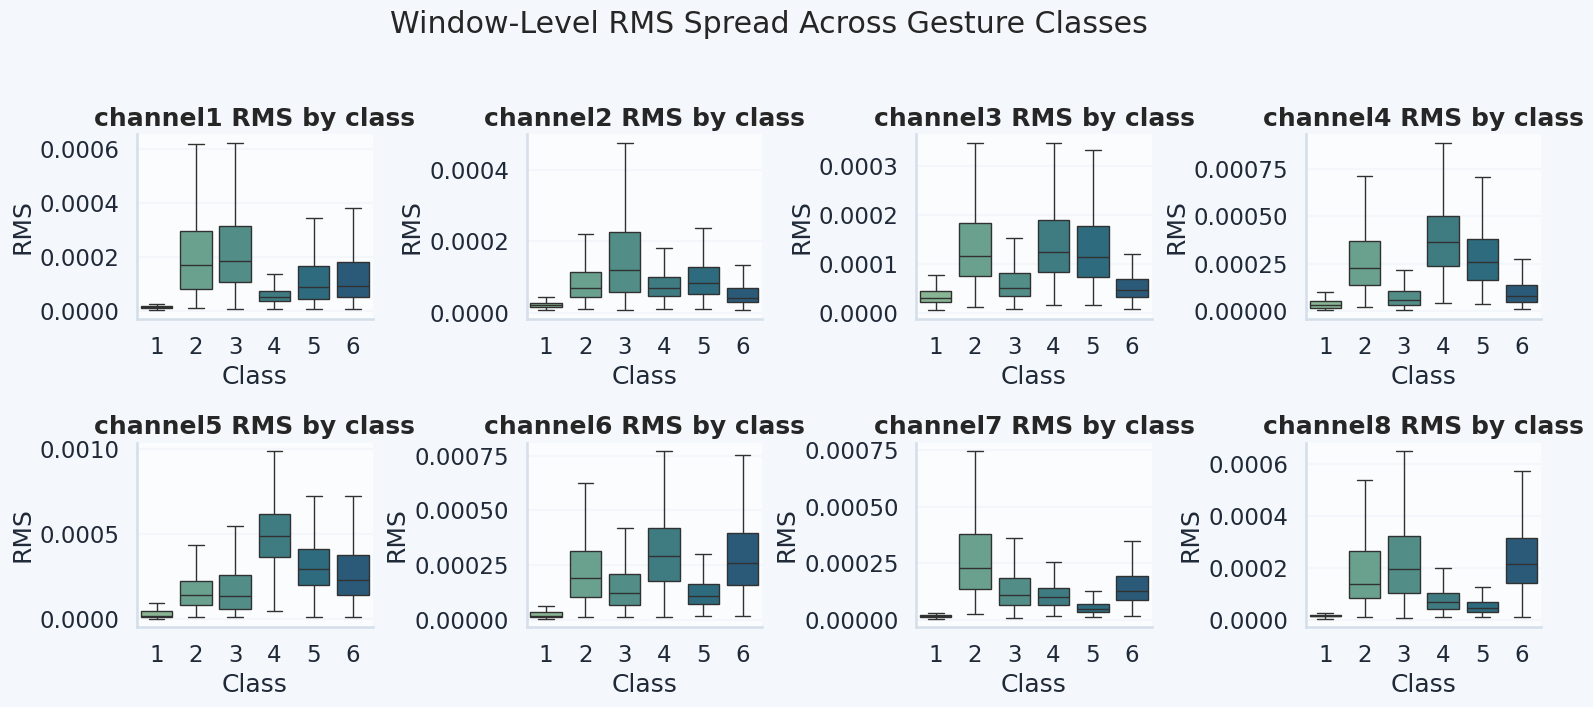

In [12]:
def window_rms_features(df, starts, window_size):
    X = np.zeros((len(starts), len(CHANNELS)), dtype=np.float32)
    for i, s in enumerate(starts):
        w = df.iloc[s:s+window_size]
        for j, ch in enumerate(CHANNELS):
            x = w[ch].to_numpy(dtype=np.float32)
            X[i, j] = np.sqrt(np.mean(x**2))
    return X

X_rms = window_rms_features(df, starts, WINDOW_SIZE)
rms_df = pd.DataFrame(X_rms, columns=CHANNELS)
rms_df["class"] = y_win

classes = sorted(np.unique(y_win).tolist())
class_box_palette = [CLASS_PALETTE[int(c)] for c in classes]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()
for j, ch in enumerate(CHANNELS):
    ax = axes[j]
    sns.boxplot(
        data=rms_df,
        x="class",
        y=ch,
        order=classes,
        palette=class_box_palette,
        showfliers=False,
        linewidth=1,
        ax=ax,
    )
    ax.set_title(f"{ch} RMS by class")
    ax.set_xlabel("Class")
    ax.set_ylabel("RMS")
    ax.grid(axis="y", alpha=0.2)
    sns.despine(ax=ax)

fig.suptitle("Window-Level RMS Spread Across Gesture Classes", y=1.02)
plt.tight_layout()
plt.show()


### 2.5 Low-Dimensional Feature Separability (PCA)

PCA on RMS features is used as a quick visual sanity check for class separability trends. It is not a final model, but it helps confirm that window-level features contain usable signal.


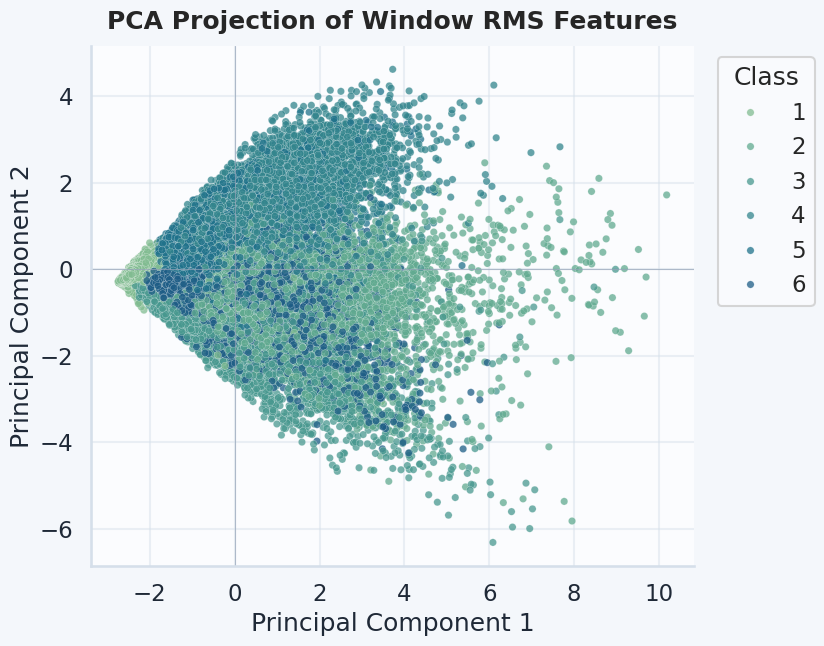

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Xz = StandardScaler().fit_transform(X_rms)
Z = PCA(n_components=2, random_state=42).fit_transform(Xz)

pca_df = pd.DataFrame({"PC1": Z[:, 0], "PC2": Z[:, 1], "class": y_win})

fig, ax = plt.subplots(figsize=(8.6, 6.8))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="class",
    palette=CLASS_PALETTE,
    s=28,
    alpha=0.75,
    linewidth=0.2,
    edgecolor="white",
    ax=ax,
)
ax.axhline(0, color="#94A3B8", linewidth=0.8, alpha=0.7)
ax.axvline(0, color="#94A3B8", linewidth=0.8, alpha=0.7)
ax.set_title("PCA Projection of Window RMS Features", pad=12)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


# 3. Training and Evaluation Protocol


### Model  Used
MLP on engineered features


In [14]:
!pip install -q optuna

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.0 MB/s eta 0:00:00


In [15]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available(): # if you have an Apple Silicon GPU
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
device


device(type='cpu')

In [16]:
WINDOW_SIZE = 100
STEP_SIZE = 50 # Changed to 50 for 50% overlap

FS = 200.0

# Must be < FS/2 = 100 Hz
BANDPASS_LOW = 10.0
BANDPASS_HIGH = 90.0

NOTCH_FREQ = 60.0   # or 50.0
NOTCH_Q = 30.0

RANDOM_STATE = 42

### 3.1 Training Data Reconstruction

The training section reloads and preprocesses data in a self-contained way so modeling cells can be run independently from EDA cells.


In [17]:
# Load row-level EMG data.
df = pd.read_csv("drive/MyDrive/Neurotech ML Edge AI/EMG-data.csv")

# `time` and subject `label` are not used in this baseline split pipeline.
df = df.drop(columns=["time", "label"], errors="ignore")

# Remove class 0 (unmarked) and class 7 (not recorded for every subject).
df = df[(df["class"] != 0) & (df["class"] != 7)].reset_index(drop=True)

CHANNELS = [f"channel{i}" for i in range(1, 9)]
df[["class"] + CHANNELS].head(), df["class"].value_counts().sort_index()


(   class  channel1  channel2  channel3  channel4  channel5  channel6  \
 0    1.0  -0.00001   0.00000  -0.00001   0.00000   0.00000  -0.00001   
 1    1.0  -0.00001  -0.00002   0.00000  -0.00001  -0.00001  -0.00001   
 2    1.0  -0.00001  -0.00002   0.00000  -0.00001  -0.00001  -0.00001   
 3    1.0  -0.00001  -0.00002   0.00000  -0.00001  -0.00001  -0.00001   
 4    1.0  -0.00001  -0.00002   0.00000  -0.00001  -0.00001  -0.00001   
 
    channel7  channel8  
 0  -0.00001   0.00001  
 1  -0.00003  -0.00002  
 2  -0.00003  -0.00002  
 3  -0.00003  -0.00002  
 4  -0.00003  -0.00002  ,
 class
 1.0    250055
 2.0    243193
 3.0    249494
 4.0    251570
 5.0    251733
 6.0    253009
 Name: count, dtype: int64)

In [18]:
def make_window_starts(n_rows, window_size, step_size):
    return list(range(0, n_rows - window_size + 1, step_size))

def window_labels(df, starts, window_size):
    y = []
    for s in starts:
        w = df.iloc[s:s+window_size]
        y.append(int(w["class"].mode().iloc[0]))
    return np.array(y, dtype=np.int64)

starts = make_window_starts(len(df), WINDOW_SIZE, STEP_SIZE)
y_raw = window_labels(df, starts, WINDOW_SIZE)

np.unique(y_raw), len(starts)


(array([1, 2, 3, 4, 5, 6]), 29980)

### 3.2 Label Indexing and Split Strategy

Gesture labels are remapped to contiguous indices for model compatibility. A stratified split preserves class proportions between train and validation sets.


In [19]:
from sklearn.model_selection import train_test_split, StratifiedKFold

classes = np.unique(y_raw)

# Map original class IDs to contiguous indices for model training.
class_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_class = {i:c for c,i in class_to_idx.items()}

# Verbal descriptions for each gesture class
class_id_to_name = {
    1: "hand at rest",
    2: "hand clenched in a fist",
    3: "wrist flexion",
    4: "wrist extension",
    5: "radial deviation",
    6: "ulnar deviation"
}

# Create ordered list of class names for classification reports
class_names = [class_id_to_name[c] for c in sorted(classes)]

y = np.vectorize(class_to_idx.get)(y_raw).astype(np.int64)
K = len(classes)

idx = np.arange(len(starts))

# --- 1. PROPER TRAIN / VAL / TEST SPLIT ---
# First, hold out 15% as the final lock-box Test Set (NEVER used in training/tuning)
idx_train_val, test_idx = train_test_split(
    idx, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

# Next, split the remaining 85% into Train (70%) and Val (15%)
# 15 / 85 ≈ 0.17647
train_idx, val_idx = train_test_split(
    idx_train_val, test_size=0.17647, random_state=RANDOM_STATE, stratify=y[idx_train_val]
)

print("--- 3-WAY SPLIT SIZES ---")
print(f"Train size: {len(train_idx)} ({len(train_idx)/len(idx):.1%})")
print(f"Val size:   {len(val_idx)} ({len(val_idx)/len(idx):.1%})")
print(f"Test size:  {len(test_idx)} ({len(test_idx)/len(idx):.1%})\n")

# --- 2. K-FOLD CROSS VALIDATION SETUP ---
# Your boss mentioned K-Fold. You would run this on the train_val data (before touching the test set)
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

print(f"--- {n_splits}-FOLD CV SETUP (on Train+Val) ---")
fold = 1
for kf_train_idx, kf_val_idx in skf.split(idx_train_val, y[idx_train_val]):
    print(f"Fold {fold}: Train={len(kf_train_idx)}, Val={len(kf_val_idx)}")
    fold += 1

--- 3-WAY SPLIT SIZES ---
Train size: 20986 (70.0%)
Val size:   4497 (15.0%)
Test size:  4497 (15.0%)

--- 5-FOLD CV SETUP (on Train+Val) ---
Fold 1: Train=20386, Val=5097
Fold 2: Train=20386, Val=5097
Fold 3: Train=20386, Val=5097
Fold 4: Train=20387, Val=5096
Fold 5: Train=20387, Val=5096


## 4. Feature-Based Modeling (MLP + XGBoost)

This branch transforms each EMG window into compact time-domain descriptors and treats the problem as structured tabular classification.

### Features Extracted per Channel
- `RMS`: signal energy
- `MAV`: mean absolute amplitude
- `WL`: waveform complexity via cumulative change
- `ZC`: sign transitions with thresholding
- `SSC`: local slope-direction changes
- `VAR`: amplitude dispersion

With 8 channels, this yields a dense but tractable feature vector per window.

### Why Start With Feature Models
- Fast to train and tune
- Strong baseline in many EMG settings
- Easier debugging and interpretation before moving to higher-capacity sequence models


In [20]:
# Per-window 1D EMG feature extractor.
def emg_features_1d(x: np.ndarray) -> np.ndarray:
    rms = np.sqrt(np.mean(x**2))
    mav = np.mean(np.abs(x))
    wl  = np.sum(np.abs(np.diff(x)))
    thr = 1e-3
    zc  = np.sum(((x[:-1] * x[1:]) < 0) & (np.abs(x[:-1] - x[1:]) > thr))
    ssc = np.sum((np.diff(x[:-1]) * np.diff(x[1:])) < 0)
    var = np.var(x)
    return np.array([rms, mav, wl, zc, ssc, var], dtype=np.float32)

FEAT_NAMES = ["rms","mav","wl","zc","ssc","var"]

def build_feature_matrix(df, starts, window_size):
    X = np.zeros((len(starts), len(CHANNELS) * len(FEAT_NAMES)), dtype=np.float32)
    for i, s in enumerate(starts):
        w = df.iloc[s:s+window_size]
        col = 0
        for ch in CHANNELS:
            feats = emg_features_1d(w[ch].to_numpy(dtype=np.float32))
            X[i, col:col+len(FEAT_NAMES)] = feats
            col += len(FEAT_NAMES)
    return X

X_feat = build_feature_matrix(df, starts, WINDOW_SIZE)
X_feat.shape


(29980, 48)

### 4.1 Train-Only Standardization

Feature scaling is fit on the training subset and then applied to validation data, preventing information leakage.


In [21]:
# For final single-model training (early stopping)
Xf_train, Xf_val = X_feat[train_idx], X_feat[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

scaler_feat = StandardScaler()
Xf_train = scaler_feat.fit_transform(Xf_train).astype(np.float32)
Xf_val   = scaler_feat.transform(Xf_val).astype(np.float32)

# For K-Fold CV during Optuna hyperparameter search
Xf_tv = X_feat[idx_train_val]
y_tv = y[idx_train_val]

# For final locked-box inference (test set)
Xf_test = X_feat[test_idx]
y_test = y[test_idx]
Xf_test = scaler_feat.transform(Xf_test).astype(np.float32)

print(f"Single Train shape: {Xf_train.shape}")
print(f"Single Val shape:   {Xf_val.shape}")
print(f"Combined Train+Val shape (for CV): {Xf_tv.shape}")
print(f"Test shape (Locked): {Xf_test.shape}")
print("K:", K)

Single Train shape: (20986, 48)
Single Val shape:   (4497, 48)
Combined Train+Val shape (for CV): (25483, 48)
Test shape (Locked): (4497, 48)
K: 6


In [22]:
def make_loaders_features(X_train, y_train, X_val, y_val, batch_size):
    X_train_t = torch.from_numpy(X_train).float()
    y_train_t = torch.from_numpy(y_train).long()
    X_val_t   = torch.from_numpy(X_val).float()
    y_val_t   = torch.from_numpy(y_val).long()

    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds   = TensorDataset(X_val_t, y_val_t)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=max(256, batch_size), shuffle=False, num_workers=0)
    return train_dl, val_dl


In [23]:
class MLP(nn.Module):
    def __init__(self, d_in, d_out, hidden, n_layers, dropout):
        super().__init__()
        layers = []
        d = d_in
        for _ in range(n_layers):
            layers += [nn.Linear(d, hidden), nn.ReLU(), nn.Dropout(dropout)]
            d = hidden
        layers += [nn.Linear(d, d_out)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def compute_class_weights(y_train, K):
    counts = np.bincount(y_train, minlength=K).astype(np.float32)
    w = (counts.sum() / np.maximum(counts, 1.0))
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32)

@torch.no_grad()
def eval_f1_loss(model, dl, crit, device):
    model.eval()
    all_p, all_y = [], []
    total_loss, total = 0.0, 0
    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = crit(logits, yb)
        total_loss += float(loss.item()) * yb.size(0)
        total += yb.size(0)
        all_p.append(logits.argmax(1).detach().cpu().numpy())
        all_y.append(yb.detach().cpu().numpy())
    y_pred = np.concatenate(all_p)
    y_true = np.concatenate(all_y)
    f1 = f1_score(y_true, y_pred, average="macro")
    return f1, total_loss / total

def train_one_epoch(model, dl, crit, opt, device, grad_clip=1.0):
    model.train()
    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = crit(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        opt.step()


### 4.2 Why Optuna for Hyperparameter Optimization

Hyperparameters interact non-linearly (depth, width, dropout, learning rate, regularization). A manual sweep is hard to scale and difficult to reproduce.

### Optimization Setup
- **Sampler:** TPE (efficient for mixed categorical/continuous spaces)
- **Pruner:** Hyperband (early-stop weak trials)
- **Objective:** maximize validation macro-F1

This setup improves search efficiency while keeping the metric aligned with the project objective.


### 4.3 MLP Search Space and Objective

The objective below tunes architecture and optimization parameters while tracking validation macro-F1 for early pruning and final selection.


In [24]:
# Optuna objective for MLP: maximize single-split validation macro-F1.
def objective_mlp(trial):
    hidden = trial.suggest_categorical("hidden", [64, 128, 256, 512])
    n_layers = trial.suggest_int("n_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    # Use the pre-scaled single train/val split
    train_dl, val_dl = make_loaders_features(Xf_train, y_train, Xf_val, y_val, batch_size)

    model = MLP(d_in=Xf_train.shape[1], d_out=K, hidden=hidden, n_layers=n_layers, dropout=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    w = compute_class_weights(y_train, K).to(device)
    crit = nn.CrossEntropyLoss(weight=w)

    best_f1 = -1.0
    patience, bad = 4, 0

    for epoch in range(1, 31):
        train_one_epoch(model, train_dl, crit, opt, device)
        f1, val_loss = eval_f1_loss(model, val_dl, crit, device)

        if f1 > best_f1 + 1e-4:
            best_f1 = f1
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

        # Prune early if the epoch's F1 score is poor
        trial.report(f1, step=epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_f1

In [25]:
study_mlp = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
                               pruner=optuna.pruners.HyperbandPruner())

study_mlp.optimize(objective_mlp, n_trials=40, show_progress_bar=True)

best = study_mlp.best_params
best


[I 2026-04-11 15:41:51,884] A new study created in memory with name: no-name-b1747968-9538-4384-9d88-417b782d9073


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-04-11 15:42:17,724] Trial 0 finished with value: 0.8552480675060351 and parameters: {'hidden': 128, 'n_layers': 1, 'dropout': 0.07799726016810132, 'lr': 0.00012184186502221769, 'weight_decay': 0.0015741890047456662, 'batch_size': 64}. Best is trial 0 with value: 0.8552480675060351.
[I 2026-04-11 15:42:40,089] Trial 1 finished with value: 0.8763790284744312 and parameters: {'hidden': 64, 'n_layers': 1, 'dropout': 0.15212112147976886, 'lr': 0.0005958389350068958, 'weight_decay': 3.905441275210794e-06, 'batch_size': 64}. Best is trial 1 with value: 0.8763790284744312.
[I 2026-04-11 15:43:08,200] Trial 2 finished with value: 0.8864572568816659 and parameters: {'hidden': 512, 'n_layers': 1, 'dropout': 0.2571172192068058, 'lr': 0.000750011895041699, 'weight_decay': 1.8997763474111273e-08, 'batch_size': 32}. Best is trial 2 with value: 0.8864572568816659.
[I 2026-04-11 15:43:08,712] Trial 3 pruned. 
[I 2026-04-11 15:43:27,268] Trial 4 finished with value: 0.8920468685825983 and parame

{'hidden': 512,
 'n_layers': 2,
 'dropout': 0.2199407492651723,
 'lr': 0.001672551455932019,
 'weight_decay': 7.03240934338348e-08,
 'batch_size': 128}

### 4.4 Final MLP Training and Evaluation

After tuning, the best MLP is retrained using the selected hyperparameters.

### Training Stabilization Choices
- class-weighted cross-entropy to reduce imbalance bias
- gradient clipping for stable optimization
- early stopping based on validation macro-F1

### Evaluation Artifacts
- validation macro-F1
- confusion matrix
- per-class precision/recall/F1

This enables both global and per-class diagnosis of behavior.


In [26]:
# train final MLP
train_dl, val_dl = make_loaders_features(Xf_train, y_train, Xf_val, y_val, best["batch_size"])

model_mlp = MLP(d_in=Xf_train.shape[1], d_out=K,
                hidden=best["hidden"], n_layers=best["n_layers"], dropout=best["dropout"]).to(device)

opt = torch.optim.AdamW(model_mlp.parameters(), lr=best["lr"], weight_decay=best["weight_decay"])
w = compute_class_weights(y_train, K).to(device)
crit = nn.CrossEntropyLoss(weight=w)

best_state, best_f1 = None, -1.0
patience, bad = 8, 0

for epoch in range(1, 81):
    train_one_epoch(model_mlp, train_dl, crit, opt, device)
    f1, _ = eval_f1_loss(model_mlp, val_dl, crit, device)
    if f1 > best_f1 + 1e-4:
        best_f1 = f1
        best_state = {k: v.detach().cpu().clone() for k,v in model_mlp.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= patience:
            break

model_mlp.load_state_dict(best_state)
print("MLP best macro-F1:", best_f1)


MLP best macro-F1: 0.9012088116134008


In [27]:
# eval MLP
model_mlp.eval()
with torch.no_grad():
    logits = model_mlp(torch.from_numpy(Xf_val).to(device)).cpu().numpy()
y_pred = logits.argmax(1)

mlp_macro_f1 = f1_score(y_val, y_pred, average="macro")
print(f"MLP macro-F1 (validation): {mlp_macro_f1:.4f}")
print("Confusion matrix:\n", confusion_matrix(y_val, y_pred))

y_true_lbl = np.vectorize(idx_to_class.get)(y_val)
y_pred_lbl = np.vectorize(idx_to_class.get)(y_pred)
print(classification_report(y_true_lbl, y_pred_lbl, digits=4, target_names=class_names))

MLP macro-F1 (validation): 0.9012
Confusion matrix:
 [[734   6   1   0   5   5]
 [  5 695  19   4   3   3]
 [ 14  26 653   5   5  45]
 [  0   3   3 654  72  24]
 [  8   8   8  58 669   3]
 [  4  14  75  14   4 648]]
                         precision    recall  f1-score   support

           hand at rest     0.9595    0.9774    0.9683       751
hand clenched in a fist     0.9242    0.9534    0.9386       729
          wrist flexion     0.8603    0.8730    0.8666       748
        wrist extension     0.8898    0.8651    0.8773       756
       radial deviation     0.8826    0.8873    0.8849       754
        ulnar deviation     0.8901    0.8538    0.8716       759

               accuracy                         0.9013      4497
              macro avg     0.9011    0.9016    0.9012      4497
           weighted avg     0.9010    0.9013    0.9010      4497



### 4.5 Quantized model

using executorch, 8-bit quantization

In [28]:
!pip install -q torchao

import os
import torch
import torch.export
from torch.export import Dim
from torch.ao.quantization.quantize_pt2e import prepare_qat_pt2e, convert_pt2e

from torch.ao.quantization.quantizer.xnnpack_quantizer import (
    XNNPACKQuantizer,
    get_symmetric_quantization_config
)

In [29]:

# Grab the exact batch size your dataloader uses
BATCH_SIZE = train_dl.batch_size

#Create the dummy input with THAT specific batch size
sample_input = torch.randn(BATCH_SIZE, 48).to(device)

# Define the batch dimension as dynamic
batch_dim = Dim("batch_size", min=1)
dynamic_shapes = {"x": {0: batch_dim}}

# Export with dynamic shapes
training_gm = torch.export.export(
    model_mlp,
    (sample_input,),
    dynamic_shapes=dynamic_shapes
).module()

# config the quantizer
quantizer = XNNPACKQuantizer()
quantizer.set_global(get_symmetric_quantization_config(is_qat=True))

# 5. Prepare the model for QAT
prepared_model = prepare_qat_pt2e(training_gm, quantizer) # inserts fake quantization nodes
prepared_model = prepared_model.to(device) # moved back to GPU

# 6. Patch the exported model to allow train/eval loops
torch.ao.quantization.allow_exported_model_train_eval(prepared_model)

# 7. Fine-tune the prepared model
opt_qat = torch.optim.AdamW(prepared_model.parameters(), lr=1e-5)

for epoch in range(1, 4):
    train_one_epoch(prepared_model, train_dl, crit, opt_qat, device)
    f1, val_loss = eval_f1_loss(prepared_model, val_dl, crit, device)
    print(f"QAT Epoch {epoch} - Val Macro-F1: {f1:.4f}")

# 8. Convert to the final quantized model
quantized_model = convert_pt2e(prepared_model)
print("Model quantized to 8-bit")

/tmp/ipykernel_4255/1570866491.py:19: DeprecationWarning: XNNPACKQuantizer is deprecated! Please use xnnpack quantizer in ExecuTorch (https://github.com/pytorch/executorch/tree/main/backends/xnnpack/quantizer) instead.
  quantizer = XNNPACKQuantizer()
/tmp/ipykernel_4255/1570866491.py:23: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = prepare_qat_pt2e(tra

QAT Epoch 1 - Val Macro-F1: 0.8987
QAT Epoch 2 - Val Macro-F1: 0.8997
QAT Epoch 3 - Val Macro-F1: 0.9008
Model quantized to 8-bit


/tmp/ipykernel_4255/1570866491.py:38: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = convert_pt2e(prepared_model)


In [56]:
# 9. Save and Compare Models
import os
import torch.ao.quantization

# Save the non-quantized (FP32) model weights
fp32_save_path = "fp32_model_baseline.pth"
torch.save(model_mlp.state_dict(), fp32_save_path)
print(f"Saved non-quantized baseline to: {os.path.abspath(fp32_save_path)}")

# Save the quantized (INT8) model weights
int8_save_path = "quantized_model_qat.pth"
torch.save(quantized_model.state_dict(), int8_save_path)
print(f"Saved quantized model to: {os.path.abspath(int8_save_path)}")

# Verification: check file sizes
fp32_size = os.path.getsize(fp32_save_path) / 1024
int8_size = os.path.getsize(int8_save_path) / 1024

print(f"\nFP32 Model Size: {fp32_size:.2f} KB")
print(f"INT8 Model Size: {int8_size:.2f} KB")
print(f"Compression Ratio: {fp32_size/int8_size:.2f}x")

# 10. Quick Inference Check (Before vs After)
model_mlp.eval()
# Use the specific function for exported models instead of .eval()
torch.ao.quantization.move_exported_model_to_eval(quantized_model)

with torch.no_grad():
    test_input = torch.from_numpy(Xf_val[:5]).to(device)
    out_fp32 = model_mlp(test_input).argmax(dim=1)
    out_int8 = quantized_model(test_input).argmax(dim=1)

print(f"\nFP32 Sample Predictions: {out_fp32.tolist()}")
print(f"INT8 Sample Predictions: {out_int8.tolist()}")

Saved non-quantized baseline to: /content/fp32_model_baseline.pth
Saved quantized model to: /content/quantized_model_qat.pth

FP32 Model Size: 1139.22 KB
INT8 Model Size: 1423.00 KB
Compression Ratio: 0.80x

FP32 Sample Predictions: [2, 1, 2, 0, 1]
INT8 Sample Predictions: [2, 1, 2, 0, 1]


## 5. Export for Edge Deployment (ONNX)

Here we convert the trained PyTorch model to ONNX format so it can be deployed on the Raspberry Pi using ONNX Runtime.

In [31]:
!pip install -q onnx onnxruntime onnxscript

import torch
import onnx
import onnxruntime as ort
from onnxruntime.quantization import quantize_dynamic, QuantType

In [57]:
def onnx_convert(base_model: torch.nn.Module, model_file: str, shape: tuple, name: str, ops_v: int = 17):  # ← 17, not 18
    base_model.load_state_dict(torch.load(model_file, map_location=torch.device('cpu'), weights_only=True))
    base_model.eval()

    tens = torch.randn(shape)

    regular_onnx_name = f"{name}.onnx"
    torch.onnx.export(
        base_model,
        (tens,),
        regular_onnx_name,
        export_params=True,
        opset_version=ops_v,
        input_names=['input'],
        output_names=['output']
    )
    print(f"Successfully exported regular model to {regular_onnx_name}")

    quantized_onnx_name = f"{name}_quantized.onnx"

    quantize_dynamic(
        model_input=regular_onnx_name,
        model_output=quantized_onnx_name,
        weight_type=QuantType.QUInt8,
        optimize_model=False   # ← prevents the broken shape inference pass
    )
    print(f"Successfully exported quantized model to {quantized_onnx_name}")

In [58]:
import onnxruntime as ort
from onnxruntime.quantization import quantize_static, QuantType, CalibrationDataReader

# 1. Calibration Reader from helper.py
class DLCalibrationReader(CalibrationDataReader):
    def __init__(self, dataloader, input_name="input"):
        self.iterator = iter(dataloader)
        self.input_name = input_name

    def get_next(self):
        try:
            batch = next(self.iterator)
            if isinstance(batch, (tuple, list)):
                batch = batch[0]
            if hasattr(batch, "detach"):
                batch = batch.detach().cpu().numpy()

            # Slicing to batch size 1 to match the static input shape (1, 48) of our ONNX model
            return {self.input_name: batch[0:1]}

        except StopIteration:
            return None

# 2. Combined Export & Static Quantization
def onnx_convert_static(base_model: torch.nn.Module, model_file: str, shape: tuple, name: str, dataloader, ops_v: int = 16):
    base_model.load_state_dict(torch.load(model_file, map_location=torch.device('cpu'), weights_only=True))
    base_model.eval()

    tens = torch.randn(shape)
    regular_onnx_name = f"{name}.onnx"

    torch.onnx.export(
        base_model,
        (tens,),
        regular_onnx_name,
        export_params=True,
        opset_version=ops_v,
        input_names=['input'],
        output_names=['output']
    )
    print(f"Successfully exported regular model to {regular_onnx_name}")

    quantized_onnx_name = f"{name}_quantized.onnx"

    quantize_static(
        model_input=regular_onnx_name,
        model_output=quantized_onnx_name,
        calibration_data_reader=DLCalibrationReader(dataloader),
        activation_type=QuantType.QUInt8,
        weight_type=QuantType.QInt8,
        per_channel=True,
        reduce_range=True
    )
    print(f"Successfully exported static quantized model to {quantized_onnx_name}")

# 3. Execution
input_shape = (1, Xf_train.shape[1])

onnx_convert_static(
    base_model=model_mlp,
    model_file='fp32_model_baseline.pth',
    shape=input_shape,
    name='emg_mlp_model',
    dataloader=train_dl,
    ops_v=16
)

W0411 17:22:42.368000 4255 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 16 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Successfully exported regular model to emg_mlp_model.onnx


Successfully exported static quantized model to emg_mlp_model_quantized.onnx


### 5.1 Export Test Data for Edge Evaluation
Save the test set to disk so it can be transferred to the Raspberry Pi for local ONNX Runtime evaluation.

In [52]:
import numpy as np
import os

# Save the pre-scaled test features and integer labels to .npy files
np.save('X_test.npy', Xf_test)
np.save('y_test.npy', y_test)

print(f"Saved X_test.npy (Size: {os.path.getsize('X_test.npy') / 1024:.2f} KB)")
print(f"Saved y_test.npy (Size: {os.path.getsize('y_test.npy') / 1024:.2f} KB)")

Saved X_test.npy (Size: 843.31 KB)
Saved y_test.npy (Size: 35.26 KB)
